In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV


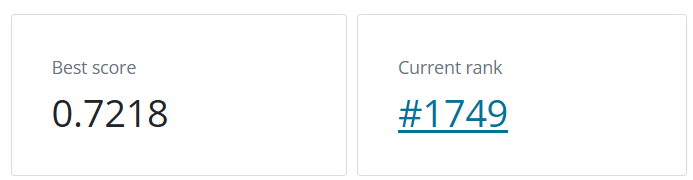

## Preprocesamiento

### Visualizacion de los datos

In [2]:
X_train = pd.read_csv("train_values.csv", delimiter=',', index_col="building_id")
y_train = pd.read_csv("train_labels.csv", delimiter=',', index_col="building_id")
X_test = pd.read_csv("test_values.csv", delimiter=',', index_col="building_id")

In [3]:
X_train.shape

(260601, 38)

In [4]:
y_train.shape

(260601, 1)

In [5]:
X_train

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
building_id,,,,,,,,,,,,,,,,,,,,,
802906,6,487,12198,2,30,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,0
28830,8,900,2812,2,10,8,7,o,r,n,...,0,0,0,0,0,0,0,0,0,0
94947,21,363,8973,2,10,5,5,t,r,n,...,0,0,0,0,0,0,0,0,0,0
590882,22,418,10694,2,10,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,0
201944,11,131,1488,3,30,8,9,t,r,n,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688636,25,1335,1621,1,55,6,3,n,r,n,...,0,0,0,0,0,0,0,0,0,0
669485,17,715,2060,2,0,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,0
602512,17,51,8163,3,55,6,7,t,r,q,...,0,0,0,0,0,0,0,0,0,0


In [6]:
X_train.describe()

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
count,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,0.034332,...,0.064378,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119
std,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,0.182081,...,0.245426,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364
min,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
y_train

,damage_grade
building_id,
802906,3
28830,2
94947,3
590882,2
201944,3
...,...
688636,2
669485,3
602512,3


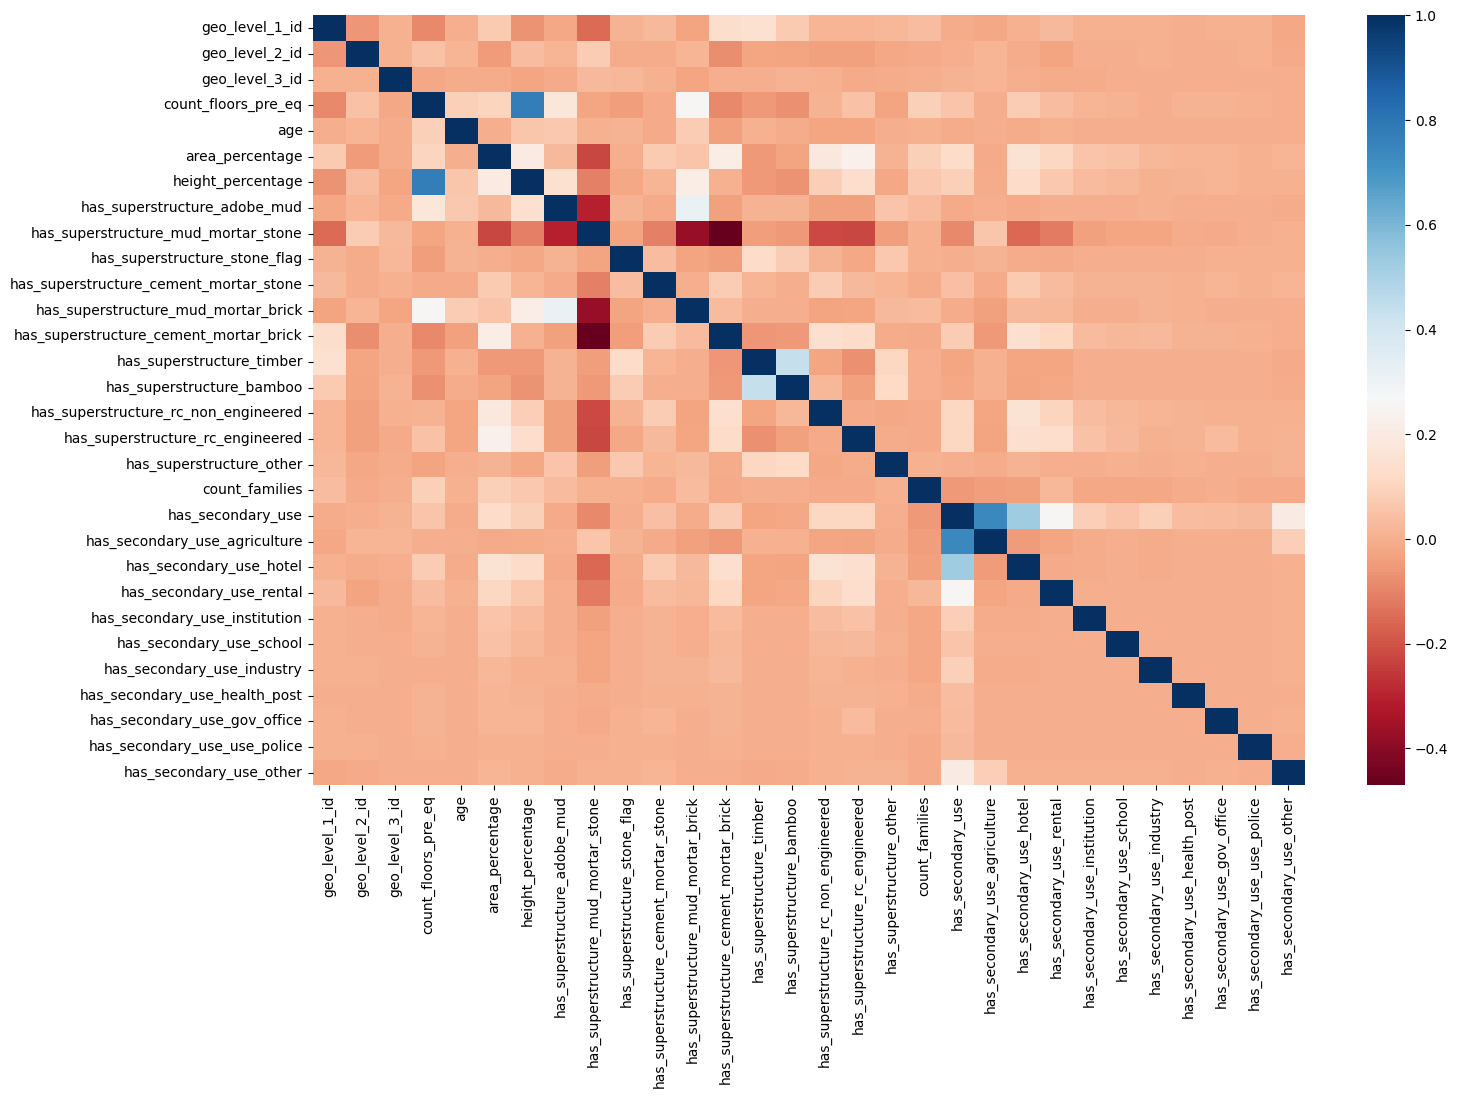

In [8]:
df_numeric = X_train.select_dtypes(include=['number'])
corr = df_numeric.corr()

# Graficamos
plt.figure(figsize=(16, 10))
sns.heatmap(corr, annot=False, cmap='RdBu')
plt.show()

### Limpieza de los datos

Observando los datos vi que el area promedio es de 8 pero vi que habia valores con 100 de area asi que intente ver si podria ser un valor atipico, sin embargo, veo que hay varios valores que proguesivamente se esta acercando al 100 por lo que no los considerares outliers

In [9]:
X_train["area_percentage"][X_train["area_percentage"] > 50].value_counts().sort_index(ascending=True)

area_percentage
51      3
52     23
53      7
54      8
55      1
56      7
57     15
58      9
59      4
60      2
61      4
62      3
63      4
64      4
65      5
66     10
67      8
69      2
70      7
72      6
73      3
75      1
76      2
77      8
78      1
80      1
82      1
83      3
84      3
85      4
86      5
90      1
96      3
100     1
Name: count, dtype: int64

En el apartado de age tambien observe un valo maximo de 995 que parece ser atipico por lo que lo elimine del dataframe, haciendo una prueba pase de 0.7218 de score a 0.7221 una diferencia poco relevante aun asi por ahora los quitare 

In [10]:
X_train["age"][X_train["age"] > 100].value_counts()

age
995    1390
120     180
150     142
200     106
110     100
105      89
125      37
115      21
130       9
140       9
180       7
170       6
160       6
135       5
175       5
190       3
145       3
165       2
195       2
155       1
185       1
Name: count, dtype: int64

In [11]:
mask = X_train[X_train['age'] == 995].index
X_train.drop(mask, inplace=True)
y_train.drop(mask, inplace=True)

In [12]:
X_train.dtypes

geo_level_1_id                             int64
geo_level_2_id                             int64
geo_level_3_id                             int64
count_floors_pre_eq                        int64
age                                        int64
area_percentage                            int64
height_percentage                          int64
land_surface_condition                    object
foundation_type                           object
roof_type                                 object
ground_floor_type                         object
other_floor_type                          object
position                                  object
plan_configuration                        object
has_superstructure_adobe_mud               int64
has_superstructure_mud_mortar_stone        int64
has_superstructure_stone_flag              int64
has_superstructure_cement_mortar_stone     int64
has_superstructure_mud_mortar_brick        int64
has_superstructure_cement_mortar_brick     int64
has_superstructure_t

In [13]:
categorical_columns = X_train.select_dtypes(include=['object']).columns

encoder = OrdinalEncoder()
X_train[categorical_columns] = encoder.fit_transform(X_train[categorical_columns])
X_test[categorical_columns] = encoder.transform(X_test[categorical_columns])

Tuve que cambiar los dtypes porque me dio error de Memoria con los 260k datos asi que intente reducir cambian a un tipo de dato mas pequeño

In [14]:
X_train = X_train.astype('int32')
X_test = X_test.astype('int32')

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Models

In [16]:
#rfc_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
#rfc_model.fit(X_train, y_train)

In [17]:
#y_pred = rfc_model.predict(X_test)

Con random forest sin optimizar consegui una puntuacion de .7218

Ahora probare optimizando el modelo

In [18]:
param_dist = {"n_estimators": [200, 225, 250, 275, 300], # Number of trees in random forest
               "min_samples_split": [2], #  Minimum number of samples required to split a node
                "min_samples_leaf": [2], # Minimum number of samples required at each leaf node
            }

In [ ]:
grid_rfc = GridSearchCV(estimator = RandomForestClassifier(), param_grid= param_dist, scoring = "f1_micro", cv = 3, n_jobs=-1)
grid_rfc.fit(X = X_train, y = y_train)

KeyboardInterrupt: 

In [ ]:
best_model_rfc = grid_rfc.best_estimator_
y_pred = best_model_rfc.predict(X_test)
print("Mejores parámetros para Random Forest:", grid_rfc.best_params_)

C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Mejores parámetros para Random Forest: {'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


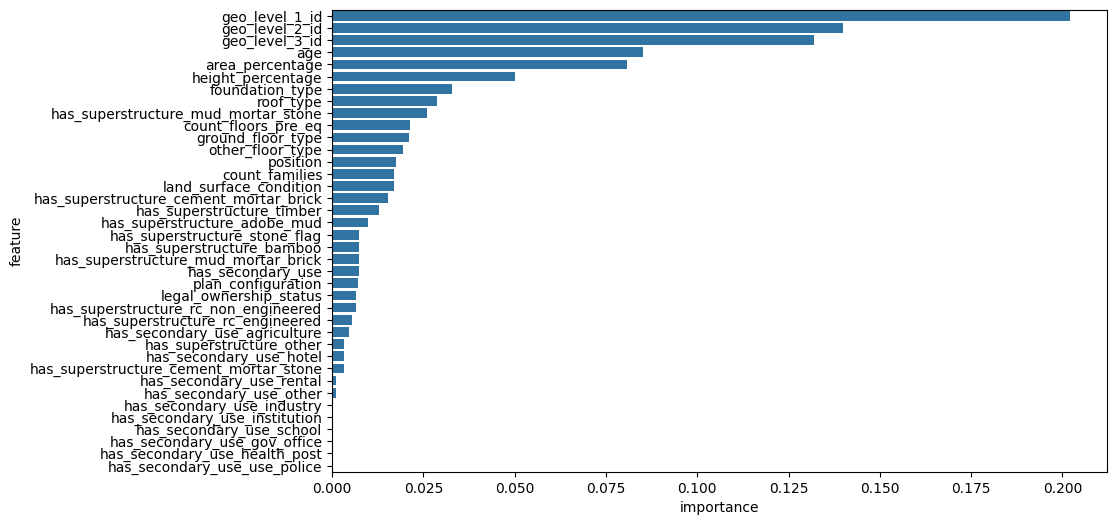

In [ ]:
features_imp = best_model_rfc.feature_importances_
columns = X_train.columns
feature_importance_df = pd.DataFrame({'feature': columns, 'importance': features_imp})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.show()

In [ ]:
resultados = pd.DataFrame({
    'building_id': X_test.index,
    'damage_grade': y_pred
})
resultados.to_csv('resultados.csv', index=False)